# Booking Cancellation Prediction Model

## Customer Retention & Predictive Analytics for Hospitality Industry

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [3]:
import os

for root, dirs, files in os.walk("C:\\Users\\DELL"):
    if "bookings.csv" in files:
        print(os.path.join(root, "bookings.csv"))
        break

C:\Users\DELL\bookings.csv


In [4]:
import os

for root, dirs, files in os.walk("C:\\Users\\DELL"):
    if "cleaned_hospitality_analysis.csv" in files:
        print(os.path.join(root, "cleaned_hospitality_analysis.csv"))

C:\Users\DELL\AppData\Local\Packages\5319275A.WhatsAppDesktop_cv1g1gvanyjgm\LocalState\sessions\CB9B99BAA3ECA7A988620581A581F6CA0D8125FA\transfers\2026-20\cleaned_hospitality_analysis.csv
C:\Users\DELL\OneDrive\Desktop\Travel-tourism-customer-retention-analysis-main\data\cleaned\cleaned_hospitality_analysis.csv


In [5]:
df = pd.read_csv(
    r"C:\Users\DELL\AppData\Local\Packages\5319275A.WhatsAppDesktop_cv1g1gvanyjgm\LocalState\sessions\CB9B99BAA3ECA7A988620581A581F6CA0D8125FA\transfers\2026-20\cleaned_hospitality_analysis.csv"
)

df.head()

,booking_id,customer_id,hotel_id,room_id,booking_date,check_in_date,check_out_date,lead_time,adults,children,meal_plan,market_segment,booking_status,adr,total_nights,special_requests,booking_channel,discount_percentage,booking_revenue,total_guests
0,1,1635,59,1295,2024-07-25,2024-10-09,2024-10-11,76,5,0,Full Board,Online,Canceled,24161,2,4,Walk-in,0,48322,5
1,2,3308,89,483,2025-10-14,2025-11-23,2025-12-05,40,2,0,Full Board,Corporate,Canceled,18652,12,5,Website,19,223824,2
2,3,4723,24,1572,2026-05-06,2026-05-20,2026-06-04,14,5,2,Breakfast,Travel Agent,Canceled,13303,15,3,Travel Agent,17,199545,7
3,4,1983,100,911,2026-04-02,2026-04-16,2026-04-23,14,3,3,Full Board,Travel Agent,Canceled,14014,7,4,Walk-in,26,98098,6
4,5,831,49,608,2026-02-08,2026-03-07,2026-03-18,27,2,3,Breakfast,Online,Confirmed,17525,11,3,Walk-in,37,192775,5


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   booking_id           12000 non-null  int64 
 1   customer_id          12000 non-null  int64 
 2   hotel_id             12000 non-null  int64 
 3   room_id              12000 non-null  int64 
 4   booking_date         12000 non-null  object
 5   check_in_date        12000 non-null  object
 6   check_out_date       12000 non-null  object
 7   lead_time            12000 non-null  int64 
 8   adults               12000 non-null  int64 
 9   children             12000 non-null  int64 
 10  meal_plan            12000 non-null  object
 11  market_segment       12000 non-null  object
 12  booking_status       12000 non-null  object
 13  adr                  12000 non-null  int64 
 14  total_nights         12000 non-null  int64 
 15  special_requests     12000 non-null  int64 
 16  book

In [7]:
df.isnull().sum()

booking_id             0
customer_id            0
hotel_id               0
room_id                0
booking_date           0
check_in_date          0
check_out_date         0
lead_time              0
adults                 0
children               0
meal_plan              0
market_segment         0
booking_status         0
adr                    0
total_nights           0
special_requests       0
booking_channel        0
discount_percentage    0
booking_revenue        0
total_guests           0
dtype: int64

In [8]:
# Convert categorical columns into numeric

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

df.head()

,booking_id,customer_id,hotel_id,room_id,booking_date,check_in_date,check_out_date,lead_time,adults,children,meal_plan,market_segment,booking_status,adr,total_nights,special_requests,booking_channel,discount_percentage,booking_revenue,total_guests
0,1,1635,59,1295,77,148,141,76,5,0,1,2,0,24161,2,4,2,0,48322,5
1,2,3308,89,483,523,558,561,40,2,0,1,0,0,18652,12,5,3,19,223824,2
2,3,4723,24,1572,727,736,742,14,5,2,0,3,0,13303,15,3,1,17,199545,7
3,4,1983,100,911,693,702,700,14,3,3,1,3,0,14014,7,4,2,26,98098,6
4,5,831,49,608,640,662,664,27,2,3,0,2,2,17525,11,3,2,37,192775,5


In [9]:
print(df.columns)

Index(['booking_id', 'customer_id', 'hotel_id', 'room_id', 'booking_date',
       'check_in_date', 'check_out_date', 'lead_time', 'adults', 'children',
       'meal_plan', 'market_segment', 'booking_status', 'adr', 'total_nights',
       'special_requests', 'booking_channel', 'discount_percentage',
       'booking_revenue', 'total_guests'],
      dtype='object')


In [10]:
X = df.drop("booking_status", axis=1)

y = df["booking_status"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (9600, 19)
Testing Data Shape: (2400, 19)


In [12]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [13]:
print("Notebook Working")

Notebook Working


In [14]:
y_pred = model.predict(X_test)

In [15]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

Accuracy Score: 0.32625


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.31      0.20      0.24       778
           1       0.32      0.48      0.39       814
           2       0.34      0.30      0.32       808

    accuracy                           0.33      2400
   macro avg       0.33      0.32      0.31      2400
weighted avg       0.33      0.33      0.32      2400



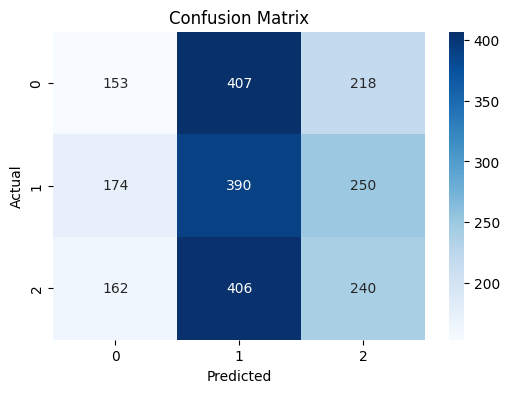

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [18]:
from sklearn.metrics import roc_auc_score

In [19]:
roc_score = roc_auc_score(
    y_test,
    model.predict_proba(X_test),
    multi_class='ovr'
)

print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.4901817681497244


In [20]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance = importance.sort_values(by='Coefficient', ascending=False)

importance.head(10)

,Feature,Coefficient
2,hotel_id,0.000581
7,lead_time,0.000196
5,check_in_date,0.000061
6,check_out_date,0.000039
13,total_nights,0.000026
3,room_id,0.000023
8,adults,0.000022
14,special_requests,0.000022
10,meal_plan,0.000019
18,total_guests,0.000010


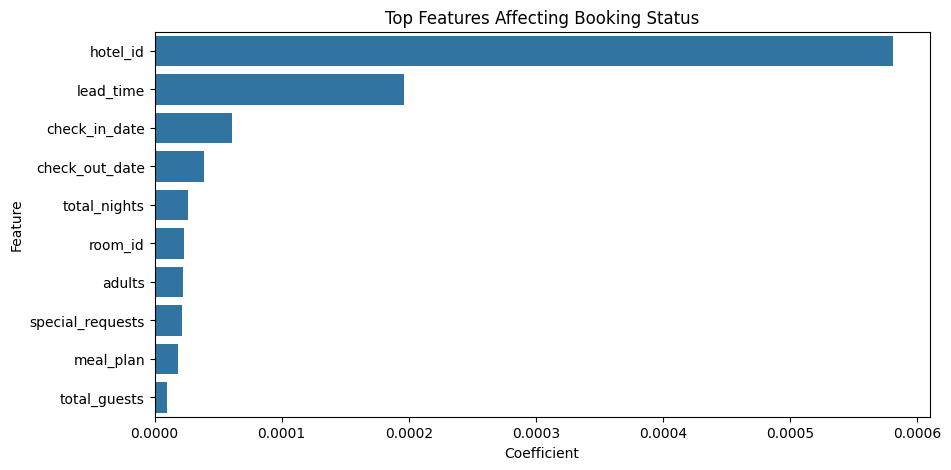

In [21]:
top_features = importance.head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=top_features
)

plt.title("Top Features Affecting Booking Status")

plt.show()

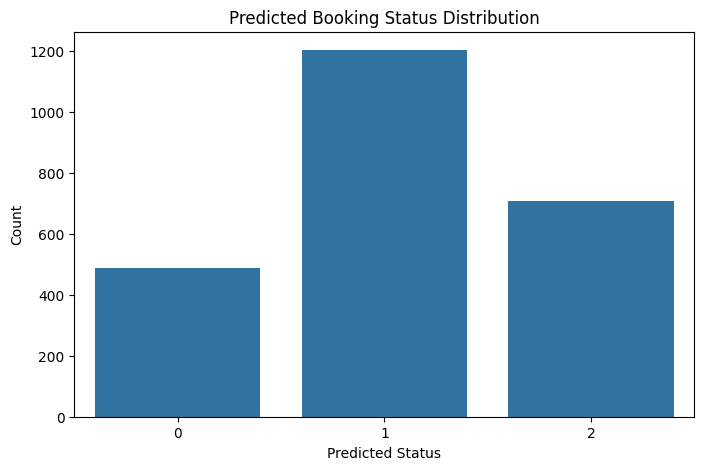

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(x=y_pred)

plt.title("Predicted Booking Status Distribution")
plt.xlabel("Predicted Status")
plt.ylabel("Count")

plt.show()

In [23]:
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

comparison_df.head(20)

,Actual,Predicted
0,1,1
1,2,1
2,2,0
3,1,1
4,1,1
5,0,1
6,2,1
7,0,1
8,1,1
9,1,1


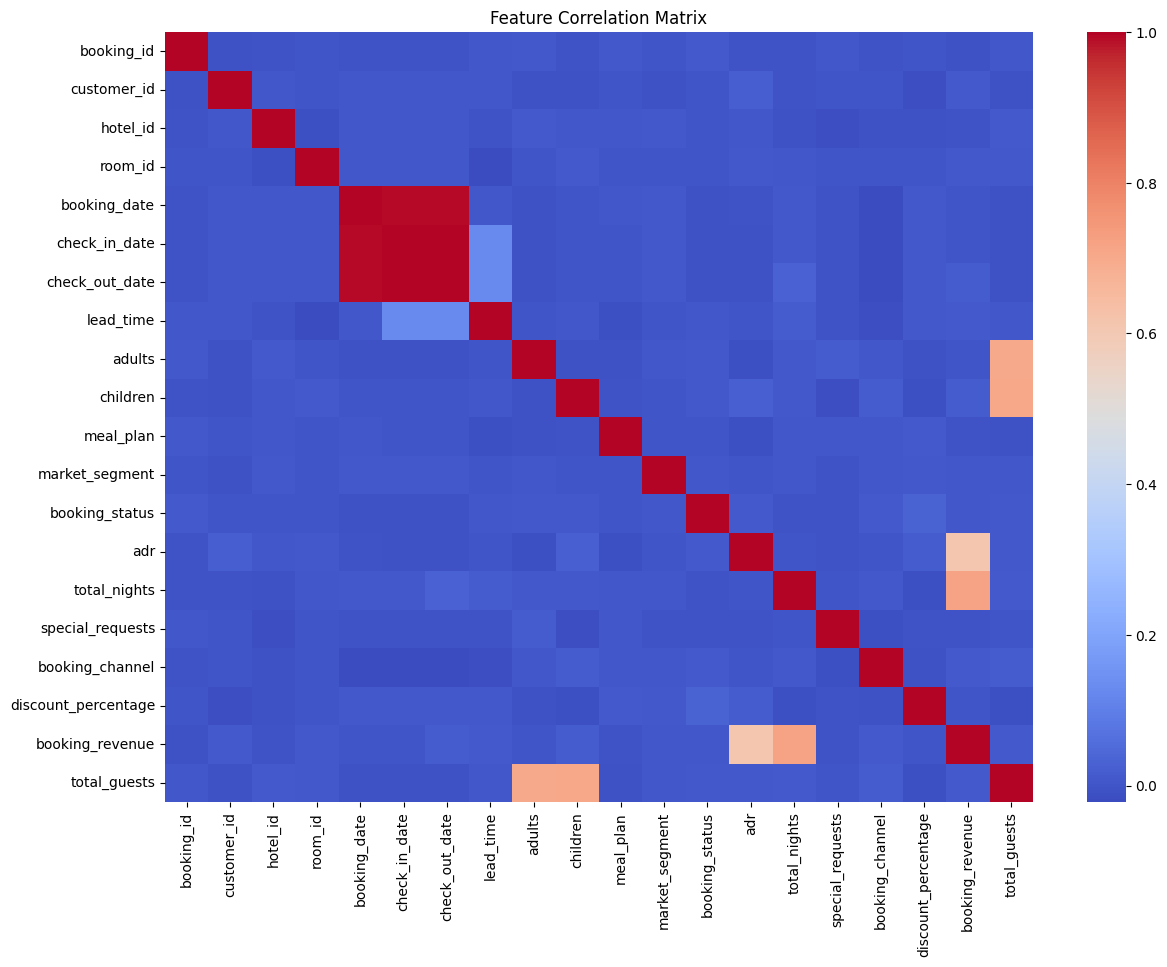

In [24]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(), cmap='coolwarm')

plt.title("Feature Correlation Matrix")

plt.show()

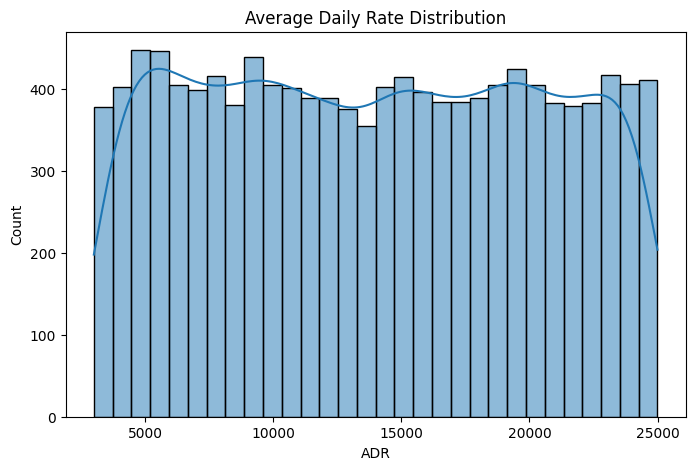

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(df['adr'], bins=30, kde=True)

plt.title("Average Daily Rate Distribution")

plt.xlabel("ADR")

plt.show()

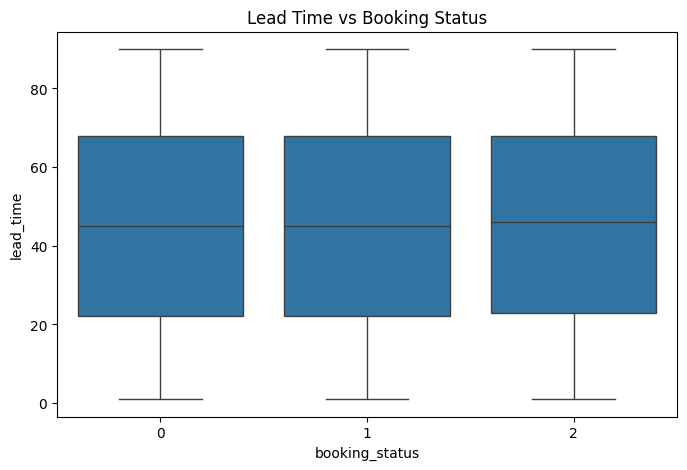

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(x='booking_status', y='lead_time', data=df)

plt.title("Lead Time vs Booking Status")

plt.show()

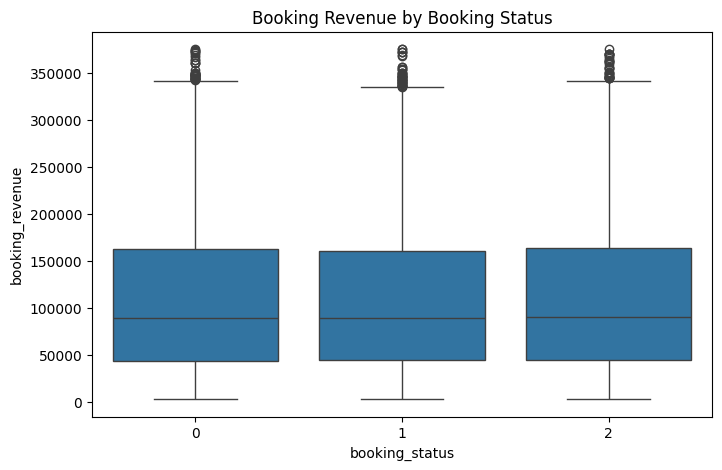

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(x='booking_status', y='booking_revenue', data=df)

plt.title("Booking Revenue by Booking Status")

plt.show()